In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from keras.datasets import fashion_mnist
#from feedforward_neural_network import FeedforwardNeuralNetwork


2025-02-26 13:04:02.714799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740555242.733437   33367 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740555242.738339   33367 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-26 13:04:02.759137: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [3]:
# Count occurrences of each class
train_counts = Counter(y_train)
test_counts = Counter(y_test)
display(x_train.shape)
display(x_test.shape)

display(y_train.shape)
display(y_test.shape)
display(train_counts)
display(test_counts)

(60000, 28, 28)

(10000, 28, 28)

(60000,)

(10000,)

Counter({9: 6000,
         0: 6000,
         3: 6000,
         2: 6000,
         7: 6000,
         5: 6000,
         1: 6000,
         6: 6000,
         4: 6000,
         8: 6000})

Counter({9: 1000,
         2: 1000,
         1: 1000,
         6: 1000,
         4: 1000,
         5: 1000,
         7: 1000,
         3: 1000,
         8: 1000,
         0: 1000})

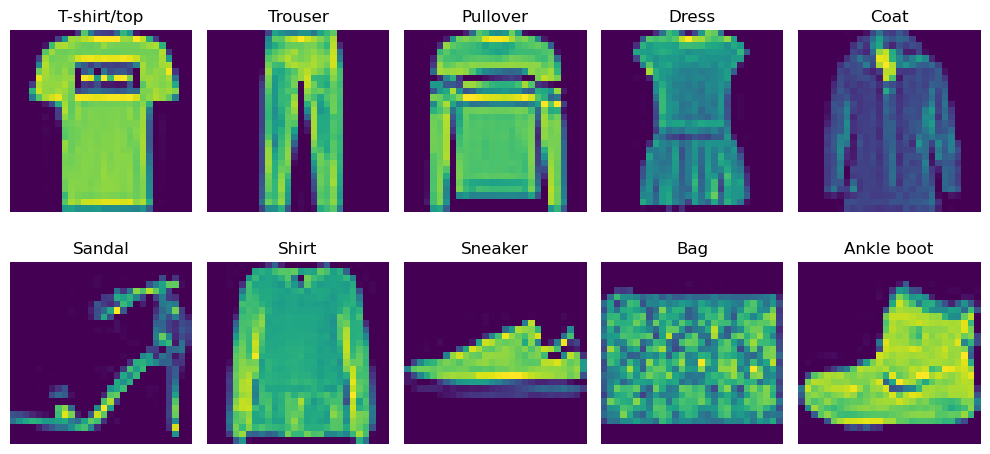

In [4]:
# Class labels in Fashion-MNIST
class_labels = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Select 1 sample per class
samples = []
for i in range(10):
    idx = np.where(y_train == i)[0][0]  # Get first occurrence of each class
    samples.append((x_train[idx], class_labels[i]))

# Plot images in a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, (image, label) in zip(axes.flatten(), samples):
    ax.imshow(image)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0
y_train, y_test = np.eye(10)[y_train], np.eye(10)[y_test]  # Convert to one-hot encoding


In [15]:
from feedforward_neural_network import FeedforwardNeuralNetwork
# Initialize model
nn = FeedforwardNeuralNetwork(layer_sizes=[784, 10], activation="sigmoid", init_method="random", learning_rate=0.01)

# Train model
nn.train(x_train, y_train, epochs=15)

# Predict test data
predictions = nn.predict(x_test[:10])
print("Predicted labels:", predictions)

Epoch 1/15, Loss: 0.0714
Epoch 2/15, Loss: 0.0758
Epoch 3/15, Loss: 0.0801
Epoch 4/15, Loss: 0.0842
Epoch 5/15, Loss: 0.0882
Epoch 6/15, Loss: 0.0918
Epoch 7/15, Loss: 0.0953
Epoch 8/15, Loss: 0.0986
Epoch 9/15, Loss: 0.1017
Epoch 10/15, Loss: 0.1046
Epoch 11/15, Loss: 0.1074
Epoch 12/15, Loss: 0.1100
Epoch 13/15, Loss: 0.1124
Epoch 14/15, Loss: 0.1147
Epoch 15/15, Loss: 0.1169
Predicted labels: [9 0 3 3 0 3 0 0 2 2]
